In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing

In [4]:
DATA_DIR = Path(r"D:\lab\cptac_prostate\data\v4\CPTAC")
OUTPUT_DIR = Path(r"D:\lab\cptac_prostate\runs\20260330_cptac_acetyl_tmt_normalized_pca")
print(DATA_DIR.exists(), OUTPUT_DIR.exists())
meta_path = DATA_DIR / "20_MetaData_03_12_2026.csv"

True False


In [5]:
meta = pd.read_csv(meta_path)
meta

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [6]:
meta_include = meta[meta["include_or_excludetumor"] == "Include"]
meta_include

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [7]:
purity_map = dict(zip(meta_include["common_ID"], meta_include["FirstCategory"]))
stage_map = dict(zip(meta_include["common_ID"], meta_include["stage"]))
gleason_map = dict(zip(meta_include["common_ID"], meta_include["Gleason_um"]))

In [8]:
meta_exclude = meta[meta["include_or_excludetumor"] == "exclude"]
meta_exclude

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
144,C3L-09492,C3L.09492.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,C3L-09497,C3L.09497.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146,C3L-06260,C3L.06260.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147,C3L-06510,C3L.06510.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,C3L-07890,C3L.07890.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,C3L-09372,C3L.09372.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,C3N-09047,C3N.09047.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,C3L-07868,C3L.07868.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,C3L-09563,C3L.09563.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,C3L-10319,C3L.10319.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
meta_normal = meta[meta["include_or_excludetumor"] == "normal"]
meta_normal

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
111,C3L-07813,C3L.07813.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,C3L-06504,C3L.06504.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,C3L-06506,C3L.06506.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,C3L-06741,C3L.06741.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,C3L-06890,C3L.06890.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,C3L-06901,C3L.06901.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,C3L-06743,C3L.06743.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,C3L-07607,C3L.07607.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,C3L-06436,C3L.06436.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,C3L-07809,C3L.07809.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
tumors_included = meta_include['common_ID'].tolist()
tumors_excluded = meta_exclude['common_ID'].tolist()
print(len(tumors_included), len(tumors_excluded))

134 16


In [11]:
normals = meta_normal['common_ID'].tolist()
print(len(normals))

33


In [ ]:
# data
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"normalized_acetyl_TMT_ratio",i.stem, re.IGNORECASE) \
         and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE) \
            and re.search(r"normalized",i.stem, re.IGNORECASE) ]
data_path = files[0]
print(data_path)
header_cols = ["gene_site","Index","SequenceWindow"]
data = pd.read_csv(data_path,sep="\t").set_index(header_cols)
data_nomiss = data.dropna()

D:\lab\cptac_prostate\data\v4\CPTAC\prostate_CPTAC_normalized_acetyl_TMT_ratio_single_site_MD.tsv


In [13]:
files

[WindowsPath('D:/lab/cptac_prostate/data/v4/CPTAC/prostate_CPTAC_normalized_acetyl_TMT_ratio_single_site_MD.tsv')]

In [14]:
data

,,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
gene_site,Index,SequenceWindow,,,,,,,,,,,,,,,,,,,,,
FKBP4_K181,ENSP00000001008_K181,LEGYYKDkLFDQREL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FKBP4_K213,ENSP00000001008_K213,RAIQRMEkGEHSIVY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FKBP4_K354,ENSP00000001008_K354,ELDSNNEkGLFRRGE,-1.093119,-0.270130,-1.218097,-0.521286,-0.677914,-0.442421,-0.805482,0.162361,-1.004223,-0.591182,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FKBP4_K76,ENSP00000001008_K76,SSLDRKDkFSFDLGK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BAIAP2L1_K106,ENSP00000005260_K106,EIIHELEkKIELDVK,0.113284,-0.196229,0.321667,0.136194,0.244108,0.340571,0.412367,-0.109698,0.287249,-0.133506,...,0.082631,0.234729,0.016033,-0.278100,-0.233119,0.002138,-0.231090,0.487034,-0.095007,-0.372055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000290315_K246,ENSP00000515567_K246,ASVLQPVkKRKVDMP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000290315_K814,ENSP00000515567_K814,VRDVFEAkARHGFCG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MACROH2A1_K196,ENSP00000515857_K196,KSLFLGQkPPQ-___,-0.047342,0.017849,0.175266,0.085559,-0.057826,-0.057197,-0.486978,0.356758,0.033362,-0.000607,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
data_nomiss

,,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
gene_site,Index,SequenceWindow,,,,,,,,,,,,,,,,,,,,,
BAIAP2L1_K106,ENSP00000005260_K106,EIIHELEkKIELDVK,0.113284,-0.196229,0.321667,0.136194,0.244108,0.340571,0.412367,-0.109698,0.287249,-0.133506,...,0.082631,0.234729,0.016033,-0.278100,-0.233119,0.002138,-0.231090,0.487034,-0.095007,-0.372055
NDUFAB1_K97,ENSP00000007516_K97,YDKIDPEkLSVNSHF,0.055842,0.462163,-0.425500,0.526706,-0.082258,0.339720,0.140771,0.359573,0.283990,0.228028,...,0.819229,0.190754,0.442369,-0.192276,-0.156949,-0.001337,-0.582786,0.405264,-0.021327,-0.588985
HEBP1_K49,ENSP00000014930_K49,ATVEVTDkPVDEALR,-0.263797,0.835233,-0.091773,0.126919,0.146340,0.345239,-0.373006,0.977700,-0.483633,0.441260,...,0.199391,-0.003665,0.074872,-0.138704,-0.027758,0.059742,-0.345674,0.153338,-0.095050,-0.270437
VDAC3_K28,ENSP00000022615_K28,GYGFGMVkIDLKTKS,0.423137,0.183397,0.272881,0.289020,0.192572,0.233055,-0.184024,-0.166429,-0.044269,0.113082,...,-0.124737,0.113123,0.031961,-1.402463,0.265893,0.087571,0.170212,0.031869,0.155850,0.577976
VDAC3_K63,ENSP00000022615_K63,GNLETKYkVCNYGLT,0.732618,-0.373442,0.357332,0.033310,0.397117,-0.432247,0.731559,-0.526551,0.080332,0.016455,...,-0.734042,-0.490265,-0.289755,-0.105263,0.072364,0.227309,0.231504,-0.206039,-0.128362,0.762779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNRNPF_K87,ENSP00000507787_K87,HRYIEVFkSHRTEMD,0.109028,0.554931,0.152599,0.597590,0.006665,0.920717,0.181567,0.085340,0.292540,-0.038155,...,-0.666233,0.072156,-0.123808,-0.028040,-0.372940,0.114383,-0.423036,0.036180,-0.147679,-0.228530
MSN_K242,ENSP00000513134_K242,RNISFNDkKFVIKPI,0.084390,-0.066740,0.300699,0.209137,0.198963,0.164624,0.084003,-0.066752,0.015376,0.226969,...,-0.749223,-0.204118,-0.190106,-0.843277,0.024152,0.078246,0.197810,-0.430754,-0.013363,-0.082712
MSN_K243,ENSP00000513134_K243,NISFNDKkFVIKPID,0.245635,-0.554918,0.419635,-0.140100,-0.043089,0.307515,-0.165004,-0.046395,0.411598,-0.244731,...,-0.097070,-0.008126,0.183955,-0.450034,-0.036185,0.073297,-0.140402,-0.072267,-0.195198,-0.251203


In [16]:
samples = data.columns.tolist()
len(samples)

178

In [17]:
set_tumors_included = set(tumors_included)
set_tumors_excluded = set(tumors_excluded)
set_normals = set(normals)
set_data = set(samples)
print((len(set_tumors_included), len(set_tumors_excluded), len(set_normals), len(set_data)))

(134, 16, 33, 178)


In [18]:
set_data - set_tumors_included - set_tumors_excluded - set_normals

{'C3L.06436.T',
 'C3L.07292.N',
 'C3L.07606.N',
 'C3L.08546.T',
 'C3L.09345.T',
 'C3L.09373.T',
 'C3L.09793.T',
 'C3L.09832.T',
 'C3L.09972.T',
 'C3L.10301.T',
 'CHTN.47295.T'}

<Axes: >

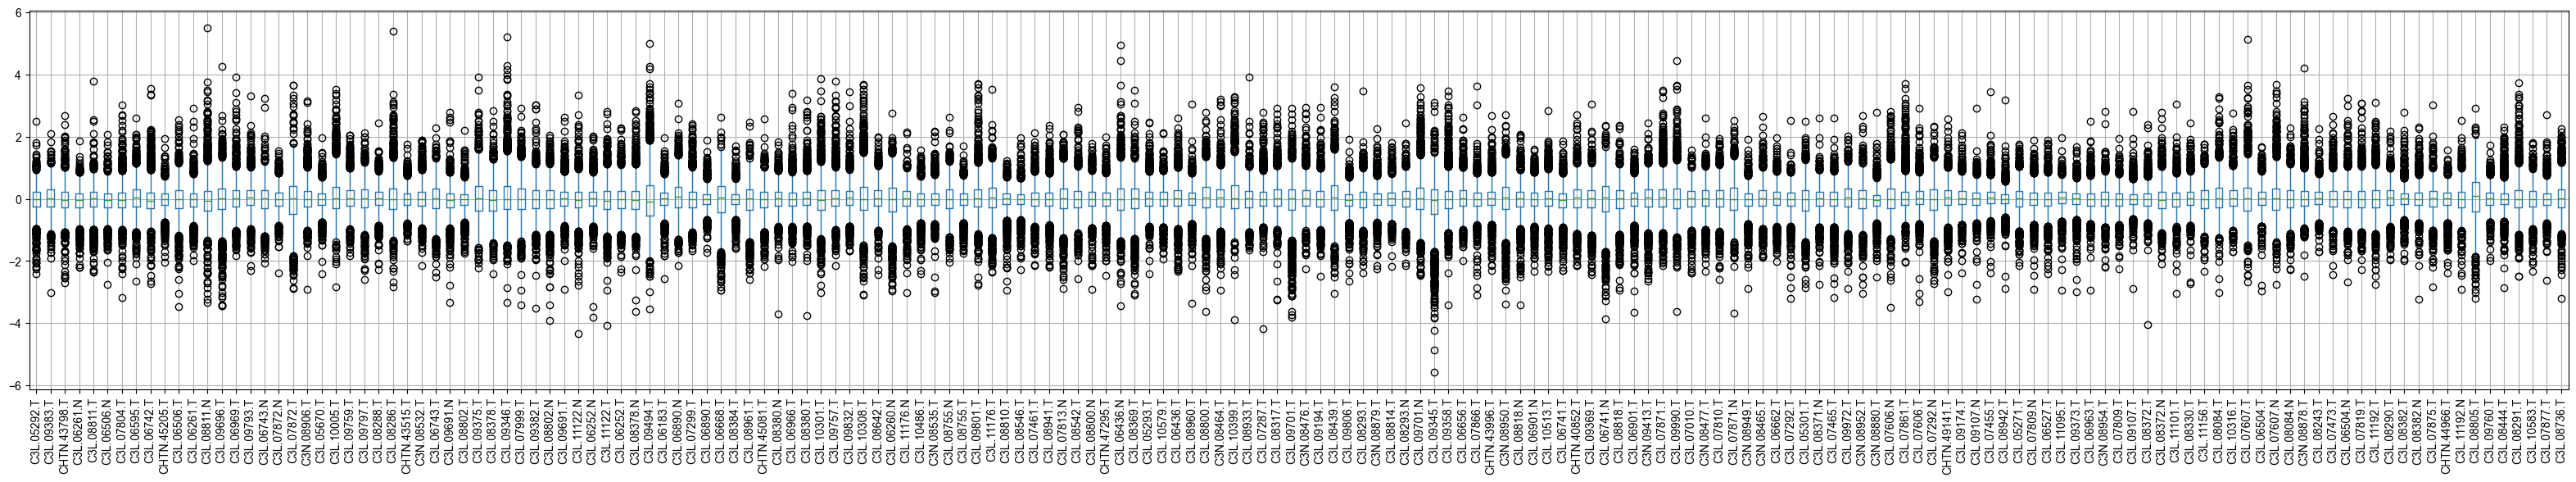

In [19]:
data.boxplot(figsize=(40,6), rot=90)

In [20]:
from omicsone_streamlit.plots.pca import plot_pca1

In [21]:
print(len(tumors_included), len(normals))

134 33


In [22]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = "Tumor"
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"

In [23]:
len(set(data.columns) & set(tumors_included))

134

In [24]:
data2 = data_nomiss.T.loc[tumors_included + normals,:]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')

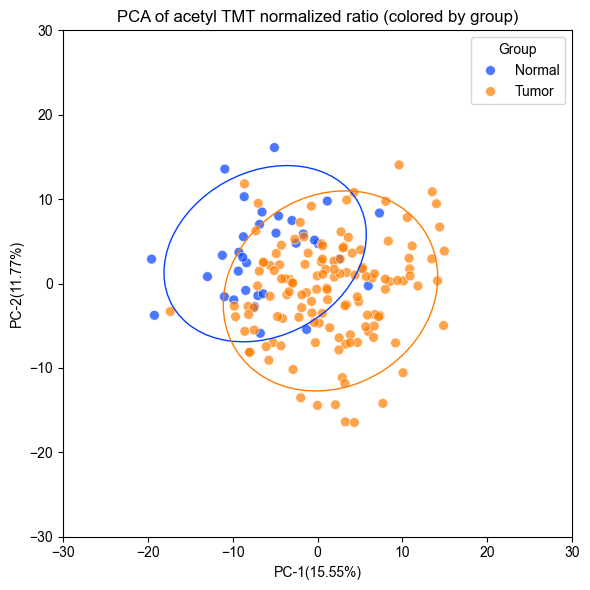

In [25]:
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=(-30,30), ylim=(-30,30), figsize=(6,6),
                    title="PCA of acetyl TMT normalized ratio (colored by group)")

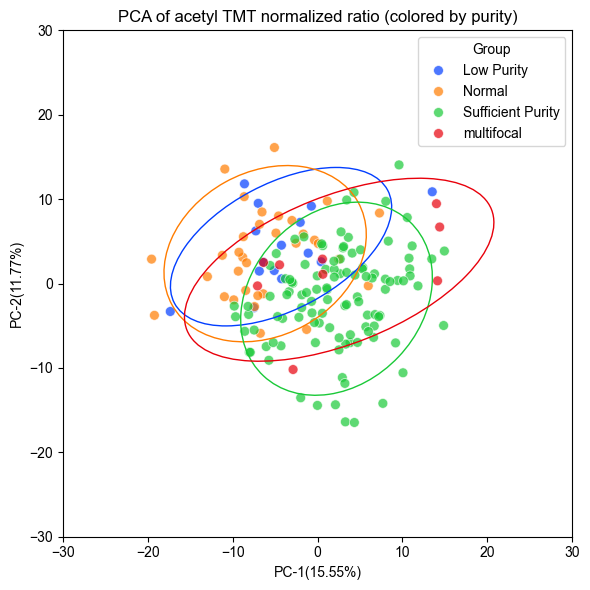

In [26]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = purity_map.get(i, "Tumor")
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=(-30,30), ylim=(-30,30), figsize=(6,6),
                    title="PCA of acetyl TMT normalized ratio (colored by purity)")

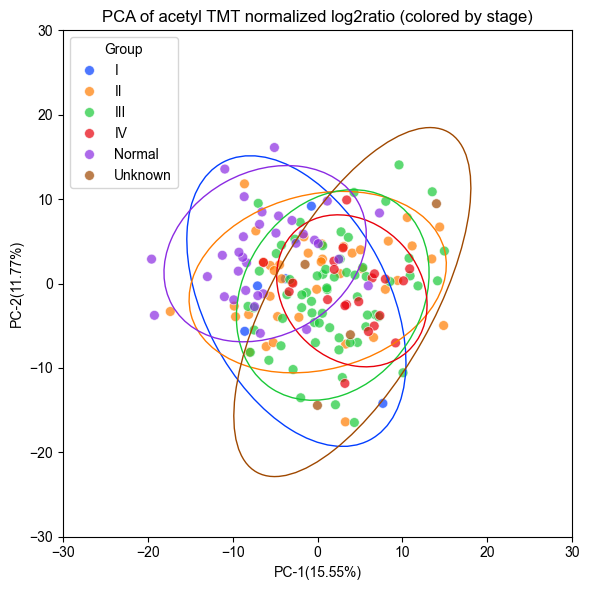

In [27]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = re.sub("[ABC]",'',stage_map.get(i, "Tumor"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=(-30,30), ylim=(-30,30), figsize=(6,6),
                    title="PCA of acetyl TMT normalized log2ratio (colored by stage)")